# **Implementación del caso de 10 Qubits.**

In [1]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q
from modules import teoria_numeros as tn

from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

In [2]:
N10 = 261980999226229

## **Implementación con 8 Qubits**

In [3]:
seed = 51

In [4]:
eightQubit = sl.schnorrCVP(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 128


In [5]:
cvpinstance = eightQubit.generate_cvp(10)

B = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [6]:
cvpResult = eightQubit.babai_algorithm(cvpinstance, delta = 0.99)
print(f'D = \n{cvpResult.D}\n')
print(f'b_op = \n{cvpResult.b_op}\n')
print(f'res_vector = \n{cvpResult.res_vector}\n')
print(f'step_sign = \n{cvpResult.step_sign}\n')
print(f'weights = \n{cvpResult.weight}\n')

D = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b_op = 
[     2      0      2      0      0      3     10      0 331994]

res_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

step_sign = 
[ 1 -1 -1 -1  1  1  1 -1]

weights = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)



In [7]:
qubo8 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, eightQubit.n)
print(qubo8.prettyprint())

Hc8, offset8 = q.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [8]:
circuit8 = q.construct_circuit(Hc8, reps = 1)
print(circuit8)

     ┌───┐ ┌────────────────┐                                           »
q_0: ┤ H ├─┤ Rz((-54)*γ[0]) ├─■───────────■────────────────■────────────»
     ├───┤ └┬─────────────┬─┘ │ZZ(-γ[0])  │                │            »
q_1: ┤ H ├──┤ Rz(35*γ[0]) ├───■───────────┼────────────────┼────────────»
     ├───┤  ├─────────────┤               │ZZ((-11)*γ[0])  │            »
q_2: ┤ H ├──┤ Rz(27*γ[0]) ├───────────────■────────────────┼────────────»
     ├───┤┌─┴─────────────┴─┐                              │ZZ(12*γ[0]) »
q_3: ┤ H ├┤ Rz((-139)*γ[0]) ├──────────────────────────────■────────────»
     ├───┤└┬───────────────┬┘                                           »
q_4: ┤ H ├─┤ Rz((-8)*γ[0]) ├────────────────────────────────────────────»
     ├───┤┌┴───────────────┴┐                                           »
q_5: ┤ H ├┤ Rz((-140)*γ[0]) ├───────────────────────────────────────────»
     ├───┤├─────────────────┤                                           »
q_6: ┤ H ├┤ Rz((-125)*γ[0]) ├─────────

In [9]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
_, optParameters8 = q.qaoa_algorithm(circuit8, Hc8, x0)

In [10]:
for param in optParameters8.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.4799726604811829
γ[0] = 0.008447652215877989


In [11]:
results8 = q.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

212
Bistring: 00000100 -> Counts: 394
Bistring: 00010011 -> Counts: 334
Bistring: 00100110 -> Counts: 311
Bistring: 00000000 -> Counts: 291
Bistring: 00000101 -> Counts: 276
Bistring: 00000010 -> Counts: 256
Bistring: 10000100 -> Counts: 234
Bistring: 00010010 -> Counts: 234
Bistring: 01010110 -> Counts: 230
Bistring: 00010111 -> Counts: 225
Bistring: 10010100 -> Counts: 223
Bistring: 00001010 -> Counts: 222
Bistring: 01010111 -> Counts: 201
Bistring: 00000110 -> Counts: 195
Bistring: 10010010 -> Counts: 192
Bistring: 00100100 -> Counts: 191
Bistring: 00100010 -> Counts: 191
Bistring: 11010110 -> Counts: 187
Bistring: 10010110 -> Counts: 185
Bistring: 00100111 -> Counts: 184
Bistring: 01000110 -> Counts: 173
Bistring: 00010101 -> Counts: 171
Bistring: 01000100 -> Counts: 171
Bistring: 01010010 -> Counts: 168
Bistring: 00010110 -> Counts: 167
Bistring: 00100101 -> Counts: 147
Bistring: 00000001 -> Counts: 140
Bistring: 10010101 -> Counts: 132
Bistring: 00001000 -> Counts: 122
Bistring: 

In [12]:
nD8 = sl.integer_to_matrix(cvpResult.D)
vnew8 = sl.bitstring2latticeVectors(nD8, results8.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect8 in vnew8:
    print(vect8)

[    -4      3      2      0      4      3      8     -4 331995]
[     0      3      0      0      4      3      6      4 331987]
[    -2      0      4      0      8     -3      6     -4 331988]
[     2      0      2      0      0      3     10      0 331994]
[    -2      3     -2     -4      7      3      6      0 331996]
[     2      3     -2      0      2      0     11     -4 331989]
[     4      6      2      0      7      0      5     -4 331997]
[    -2      3      4      4      1      3      8      0 331986]
[    -6      0      0      8      6      0      6      0 331991]
[    -6      6      0      0      8      3      4      0 331988]
[     0      6      8      4      6      3      2      0 331994]
[    -2      3      0      0      4     -6     10      0 331993]
[    -4      0     -4      4      9      0      4      4 331992]
[    -4      6     -2      0      6      0      9     -8 331990]
[     6      6      4      4      4      0      5      0 331988]
[    -2     -3      8    

In [13]:
distances8 = utils.get_distances(vnew8, cvpinstance.t)
for dist in distances8:
    print(dist)

11.74734012447073
11.045361017187261
13.038404810405298
10.862780491200215
11.661903789690601
13.19090595827292
12.727922061357855
12.96148139681572
13.2664991614216
13.638181696985855
12.884098726725126
12.84523257866513
12.727922061357855
15.684387141358123
13.038404810405298
11.74734012447073
12.884098726725126
13.2664991614216
14.7648230602334
13.341664064126334
14.560219778561036
12.569805089976535
12.569805089976535
12.884098726725126
15.937377450509228
12.165525060596439
11.74734012447073
12.884098726725126
12.449899597988733
12.083045973594572
13.038404810405298
13.74772708486752
15.556349186104045
14.352700094407323
13.856406460551018
14.966629547095765
14.7648230602334
12.922847983320086
14.696938456699069
13.341664064126334
13.416407864998739
16.76305461424021
14.142135623730951
15.874507866387544
14.0
13.784048752090222
14.798648586948742
14.035668847618199
14.071247279470288
14.696938456699069
13.784048752090222
16.55294535724685
16.55294535724685
17.08800749063506
13.1909

In [14]:
nB8 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs8 = tn.vectors2uv_pairs(nB8, vnew8, eightQubit.n)
print(uv_pairs8)

[[19915752615267795 76]
 [261868027467189 1]
 [129352557022507225 494]
 [262079207058370 1]
 [18344544450464661 70]
 [24881396719341558 95]
 [4980419307818460 19]
 [523704989883075 2]
 [2095297617885241 8]
 [2094705767700117 8]
 [262070340406875 1]
 [88548500089421427 338]
 [26192773830301463 100]
 [1890770913674116353 7220]
 [261930391846200 1]
 [1572102054235625 6]
 [10213206469368100 39]
 [3405871519729602 13]
 [4976110986617925 19]
 [23829516041101331 91]
 [16176595594767439909 61750]
 [2096063541654225 8]
 [7864168981413437 30]
 [785826051486091 3]
 [79594097822264025 304]
 [5502683577794425 21]
 [9173316356123348 35]
 [262085885854650 1]
 [6815838201665075 26]
 [262037768531825 1]
 [262100173335000 1]
 [27239768591429625 104]
 [8708014138755186387 33250]
 [398405875629322253 1521]
 [229184353172620164 875]
 [4191878430114375 16]
 [1047223518265375 4]
 [13620692197897455 52]
 [261916113620898 1]
 [262159937104450 1]
 [262157171406240 1]
 [13457840032621651689 51376]
 [628996732641

In [15]:
sr_pairs8 = tn.uv_pairs2sr_pairs(uv_pairs8, eightQubit.N, eightQubit.smooth_bound)
print(sr_pairs8)

[]


In [16]:
probs8 = utils.get_probs(results8.values(), shots = 10_000)

In [17]:
utils.prettyprint(vnew8, distances8, probs8, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     2      0      2      0      0      3     10      0 331994]

El vector residual 
t - b_op = [ -2   0  -2   0   0  -3 -10   0  -1]

La distancia |t - b_op| = 10.863

0: Prob = 0.03940
	vnew = [    -4      3      2      0      4      3      8     -4 331995] con distancia: 11.747
1: Prob = 0.03340
	vnew = [     0      3      0      0      4      3      6      4 331987] con distancia: 11.045
2: Prob = 0.03110
	vnew = [    -2      0      4      0      8     -3      6     -4 331988] con distancia: 13.038
3: Prob = 0.02910
	vnew = [     2      0      2      0      0      3     10      0 331994] con distancia: 10.863
4: Prob = 0.02760
	vnew = [    -2      3     -2     -4      7      3      6      0 331996] con distancia: 11.662
5: Prob = 0.02560
	vnew = [     2      3     -2      0      2      0     11     -4 331989] con distancia: 13.191
6: Prob = 0.02340
	vnew = [     4      6      2      0      7      0      5     -4 331997] con distanci

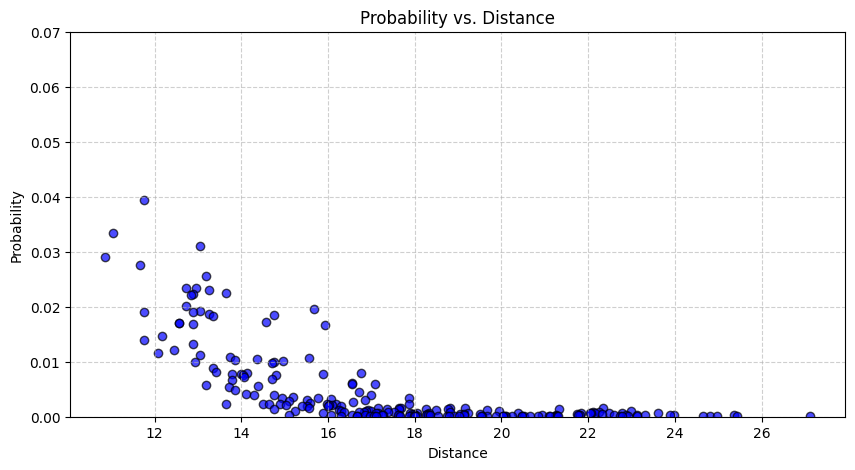

In [18]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.07) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Implementación con 10 Qubits**

In [19]:
seed = 42

In [20]:
tenQubit = sl.schnorrCVP(N10, 4, 1, seed, verbose = False)

In [21]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [22]:
cvpinstance = tenQubit.generate_cvp(10)

B = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [23]:
cvpResult = tenQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D10 = \n{cvpResult.D}\n')
print(f'b_op10 = \n{cvpResult.b_op}\n')
print(f'res_vector10 = \n{cvpResult.res_vector}\n')
print(f'step_sign10 = \n{cvpResult.step_sign}\n')
print(f'weights10 = \n{cvpResult.weight}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b_op10 = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res_vector10 = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

step_sign10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

weights10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)



In [24]:
qubo10 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, tenQubit.n)
print(qubo10.prettyprint())


Hc10, offset10 = q.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [25]:
circuit10 = q.construct_circuit(Hc10, reps= 1)
print(circuit10)

     ┌───┐ ┌────────────────┐                                               »
q_0: ┤ H ├─┤ Rz((-90)*γ[0]) ├─■─────────────■───────────────■───────────────»
     ├───┤┌┴────────────────┤ │ZZ(20*γ[0])  │               │               »
q_1: ┤ H ├┤ Rz((-107)*γ[0]) ├─■─────────────┼───────────────┼───────────────»
     ├───┤└┬────────────────┤               │ZZ((-6)*γ[0])  │               »
q_2: ┤ H ├─┤ Rz((-66)*γ[0]) ├───────────────■───────────────┼───────────────»
     ├───┤ └┬──────────────┬┘                               │ZZ((-20)*γ[0]) »
q_3: ┤ H ├──┤ Rz(115*γ[0]) ├────────────────────────────────■───────────────»
     ├───┤┌─┴──────────────┴┐                                               »
q_4: ┤ H ├┤ Rz((-111)*γ[0]) ├───────────────────────────────────────────────»
     ├───┤└┬────────────────┤                                               »
q_5: ┤ H ├─┤ Rz((-54)*γ[0]) ├───────────────────────────────────────────────»
     ├───┤ └┬─────────────┬─┘                                   

In [26]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit10, Hc10, x0)

In [27]:
print(f'Iteraciones = {monitor.iteration}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 53
Evolucion: 
[0.       0.000125]: -2.87122214025215e-14
[-0.00025    0.0003125]: -0.010549595569733169
[-0.00025    0.0003125]: -0.010549595569733169
[-0.00075  0.0005 ]: -0.0505926211114497
[-0.001       0.00084375]: -0.113528964238128
[-0.002125    0.00139063]: -0.3947715138970582
[-0.0031875   0.00235156]: -0.9805760958042883
[-0.00596875  0.00392578]: -2.8924967953977405
[-0.00948438  0.00663477]: -6.563676254571355
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01731641  0.01124756]: -12.346093372883665
[-0.01894629  0.01257458]: -12.41417034375277
[-0.01945801  0.01268445]: -12.635681616778692
[-0.01945801  0.01268445]: -12.635681616778692
[-0.01868335  0.01178531]: -12.924783633247431
[-0.02069348  0.01282756]: -13.271210084007011
[-0.02014923  0.01155041]: -14.113141321001367
[-0.02389737  0.01299633]: -15.0735913824621

In [28]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.5090286975996214
γ[0] = 0.008623538651799493


In [29]:
results10 = q.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

576
Bistring: 1001001000 -> Counts: 240
Bistring: 0001001000 -> Counts: 213
Bistring: 0000000000 -> Counts: 206
Bistring: 0000001000 -> Counts: 195
Bistring: 0001011000 -> Counts: 193
Bistring: 1001101000 -> Counts: 175
Bistring: 0001101100 -> Counts: 172
Bistring: 0001101000 -> Counts: 162
Bistring: 1001001001 -> Counts: 161
Bistring: 0000001100 -> Counts: 153
Bistring: 0000001010 -> Counts: 144
Bistring: 1011001000 -> Counts: 139
Bistring: 0001000000 -> Counts: 134
Bistring: 1001011000 -> Counts: 133
Bistring: 1000001000 -> Counts: 126
Bistring: 0001001001 -> Counts: 126
Bistring: 0000101100 -> Counts: 123
Bistring: 1000001010 -> Counts: 115
Bistring: 0000001001 -> Counts: 107
Bistring: 1001101010 -> Counts: 105
Bistring: 0100001000 -> Counts: 104
Bistring: 1011101000 -> Counts: 104
Bistring: 1000000000 -> Counts: 104
Bistring: 0100001010 -> Counts: 92
Bistring: 0000100100 -> Counts: 89
Bistring: 0000011100 -> Counts: 86
Bistring: 0000011000 -> Counts: 86
Bistring: 1001000000 -> Coun

In [30]:
nD10 = sl.integer_to_matrix(cvpResult.D)
vnew10 = sl.bitstring2latticeVectors(nD10, results10.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect10 in vnew10:
    print(vect10)

[     0      1      0      4      4      0      5      3      6      8
 331988]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     0      1      0      6      0      4      0      6      6      0
 331991]
[     0     -3      3      7      0      0      5      6      8      0
 331989]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     0      2      6      4      4      4      5      0      4      4
 331988]
[     5      4      3      4     -4      2      5      3      6      4
 331989]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[     0      1      0      8     -4     -2      5      6      6      4
 331988]
[     5      0      0      9      0      0      5      6      4      0
 331992]
[     0      6      0      7      4     -4      0      3      6      4
 331992]
[     5      3     -3      2      0     

In [31]:
distances10 = utils.get_distances(vnew10, cvpinstance.t)

In [32]:
nB10 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs10 = tn.vectors2uv_pairs(nB10, vnew10, tenQubit.n)
for pair10 in uv_pairs10:
    print(pair10)

[261871433827773 1]
[785809757098954 3]
[261991323844341 1]
[7071698751104155 27]
[2358275479138670 9]
[261912761285175 1]
[2881406685691170 11]
[261977923439050 1]
[262012871275155 1]
[37449256864542873 143]
[262013791156222 1]
[44273270057020389 169]
[1310065736807646 5]
[261965433534805 1]
[1571097732684865 6]
[262078058335730 1]
[2881166688465975 11]
[261948620080917 1]
[2358506064707975 9]
[262011783123090 1]
[524110863400845 2]
[262013355501975 1]
[523852316714727 2]
[262154507478003 1]
[2882008827066915 11]
[2881746108614485 11]
[21222711489550025 81]
[1309739882231781 5]
[261880908106545 1]
[262077260557707 1]
[1309852200204702 5]
[187261881680842038 715]
[2881986154104582 11]
[3407475551242455 13]
[44284284952292574 169]
[262054497183570 1]
[2882267946636435 11]
[1284137296744619205 4901]
[261989315983395 1]
[262118620497825 1]
[7598947436446275 29]
[2882440977138450 11]
[262076969912940 1]
[14407770361112037 55]
[523982095561925 2]
[68370542845343375 261]
[7599599091316050 29

In [33]:
sr_pairs10 = tn.uv_pairs2sr_pairs(uv_pairs10, tenQubit.N, tenQubit.smooth_bound)
print(sr_pairs10)

[]


In [34]:
probs10 = utils.get_probs(results10.values(), shots = 10_000)

In [35]:
utils.prettyprint(vnew10, distances10, probs10, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     0      1      0      6      0      4      0      6      6      0
 331991]

El vector residual 
t - b_op = [ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

La distancia |t - b_op| = 11.358

0: Prob = 0.02400
	vnew = [     0      1      0      4      4      0      5      3      6      8
 331988] con distancia: 13.856
1: Prob = 0.02130
	vnew = [     5     -1      0      3      0      0      5      6     10      4
 331990] con distancia: 14.866
2: Prob = 0.02060
	vnew = [     0      1      0      6      0      4      0      6      6      0
 331991] con distancia: 11.358
3: Prob = 0.01950
	vnew = [     0     -3      3      7      0      0      5      6      8      0
 331989] con distancia: 14.422
4: Prob = 0.01930
	vnew = [     5     -2      3      6      0      2      0      3      8      4
 331993] con distancia: 12.923
5: Prob = 0.01750
	vnew = [     0      2      6      4      4      4      5      0      4      4
 331988] con distancia: 13.038
6

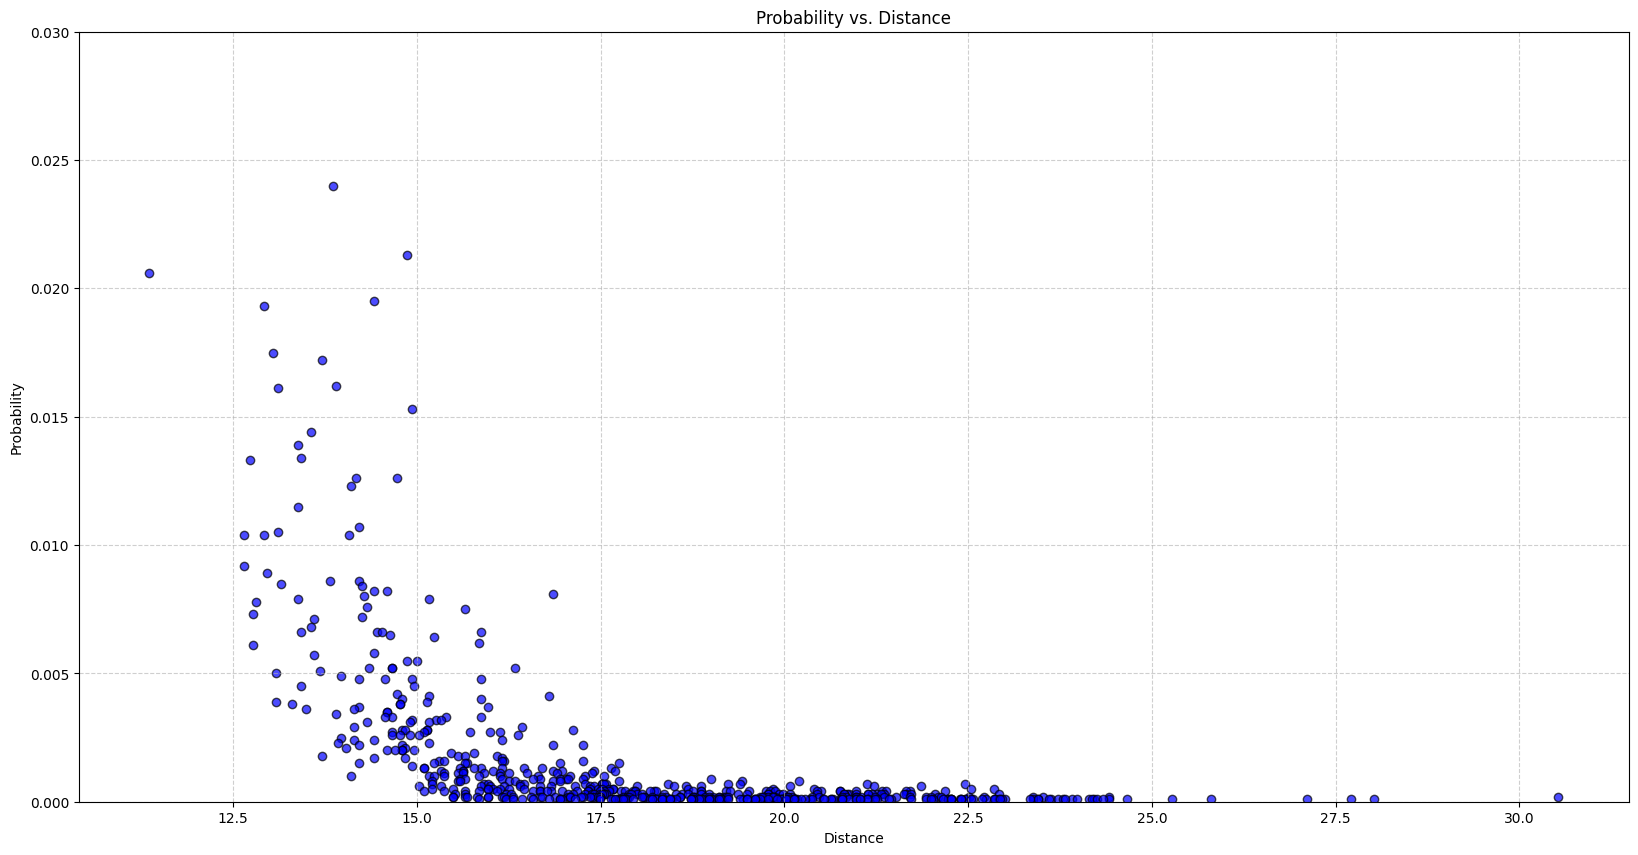

In [36]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()